In [ ]:
!ls -R

In [ ]:
# 全部一気にやるとパンクするので、まずは中身のリストだけを確認
!unzip -l bosch-production-line-performance.zip

In [ ]:
# 一番重要な「数値データ」だけをピンポイントで解凍する
!unzip -o bosch-production-line-performance.zip train_numeric.csv.zip
!unzip -o train_numeric.csv.zip

In [ ]:
# ファイルパスをここに書く（例：'data.csv' や 'bosch_log.txt'）
file_path = '/content/train_numeric.csv'

with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
  for i in range(10): # 最初の10行だけ表示 「どんなに重くても、文字化けしていても、無理やりこじ開けて中身を覗く」
      line = f.readline()
      if not line:
          break
      print(f"{i+1}: {line.strip()}")

#ポイント: errors='ignore' を入れることで、バイナリ混じりの変な文字があってもエラーで止まらずに読み飛ばしてくれます。

In [ ]:
import pandas as pd

# 1. 練習用の「ヤバい名前入りデータ」を仮に作ります
data = {
    '担当者名': ['田中太郎', '佐藤花子', '鈴木一郎'],
    'ライン名': ['Bosch_第1ライン', 'Bosch_第2ライン', 'Bosch_第1ライン'],
    'パニック指数': [0.330, 0.330, 0.120]
}
df = pd.DataFrame(data)

# 2. 【ここが魔法！】一括で「仮面」を被せます
# 担当者名を「User_数字」に、ライン名を「Line_数字」に置き換え
df['担当者名'] = ['User_' + str(i) for i in range(len(df))]
df['ライン名'] = df['ライン名'].str.replace('Bosch_第', 'Line_')

# 3. 結果を確認！
print(df)

**1. with open(file_path, 'r')**

意味: 「このファイル（file_path）を、**読み取り専用（'r' = read）**で開くよ」

メリット: with を使うことで、読み終わった瞬間にPythonが自動でファイルを閉じてくれます。巨大なファイルを開きっぱなしにしてパソコンが重くなるのを防ぐ**「お片付けの達人」**です。

**2. encoding='utf-8'**

意味: 「このファイルは UTF-8（世界標準の文字コード） で書かれている前提で読むよ」

背景: Boschのデータやエンジニアが作るファイルは、ほとんどがこの形式です。これを指定しないと、日本語や特殊な記号が「ぐちゃぐちゃの記号」になって表示されてしまいます。

**3.errors='ignore' ← これが一番重要！**

意味: 「もし読み取れない変な文字（バイナリデータや壊れた文字）があっても、無視して（ignore）突き進め！」

なぜ必要か: 巨大なファイルには、時々プログラムが理解できない「ゴミ」が混ざっています。普通ならそこで「エラー！読み込めません！」と止まってしまいますが、これを入れることで**「エラーを無視して、読めるところだけ全部出す」**というタフな動きになります。

**1. データの正体：CSV形式**
最初の 1: Id, L0_S0_F0... というのは、**「ヘッダー（列の名前）」**です。

Id: 製品一つ一つの識別番号。

L0_S0_F0: * L0: Line 0（製造ライン0）

S0: Station 0（工程0）

F0: Feature 0（計測項目0）
つまり、**「どのラインの、どの機械で、どんな数値が測られたか」**という設計図がこの1行目に詰まっています。

**2. 空白（,,,,）の意味**
2行目以降にカンマが連続しているのは、**「その工程を通らなかった」か「データが欠損している」**ことを示しています。

巨大な工場では、製品によって通るルートが違います。この「空白」をどう扱うかが、AI（機械学習）を作るエンジニアの腕の見せ所なんです。

**3. 「大きすぎて開けない」の理由**
このファイル、列（横方向）がめちゃくちゃ多いですよね？ L3_S51_F4262 まであるということは、4000項目以上のデータが1個の製品に対して紐付いていることになります。

In [ ]:
import pandas as pd

# 巨大なCSVから、最初の100行だけを読み込む（これなら一瞬！）
df_mini = pd.read_csv(file_path, nrows=100)

# 全てを表示すると横に長すぎるので、'Id' と一番右の 'Response' だけを表示
result = df_mini[['Id', 'Response']]

print("--- 最初の10件の解析結果 ---")
print(result.head(10))

# 不良品（Responseが1）が混ざっているかカウント
bad_products = df_mini[df_mini['Response'] == 1]
print(f"\n100件中、ふごうかく(1))の数: {len(bad_products)} 件")

In [ ]:
import pandas as pd

# 10万行ずつ小分けにして読み込む（メモリを節約するプロの書き方）
chunk_size = 100000
total_count = 0
total_bad = 0

print("解析開始... (巨大なデータをスキャン中) ")

# 全体をループで回して、Responseの1だけをカウントする
for chunk in pd.read_csv(file_path, chunksize=chunk_size, usecols=['Response']):
    total_count += len(chunk)
    total_bad += chunk['Response'].sum()
    print(f"{total_count}件まで確認完了...")

print("-" * 30)
print(f"全データ数: {total_count} 件")
print(f"そのうちの不合格品(1): {total_bad} 件")
print(f"不良率: {total_bad / total_count * 100:.3f} %")

**1. += は「今の数字に、新しく来た分を足して上書きする」**

これは**「累計（るいけい）」**を計算するときの合言葉です。

**普通に書くと:** 合計 = 合計 + 新しい分

**プロっぽく書くと:** 合計 += 新しい分

たとえば、あなたが工場のライン横で数取器（カチカチ）を持って立っていると想像してください。

最初の持ち分は 0 です。

最初の10万個の箱（chunk）が来ました。

その箱の中に不良品が 5個 入っていました。

カチカチと5回押して、今の合計は 5 になります。これが total_bad += 5 です。

次の10万個の箱が来ました。不良品が 3個 でした。

またカチカチと3回押して、合計は 8 になります。

これを100万個分終わるまで繰り返すのが、このコードの正体です。

**2. それぞれの中身の意味**

len(chunk)

len は Length（長さ）。つまり「この箱の中に**全部で何個**の製品が入っているか」を数えています。

10万行ずつ読み込んでいるので、基本は 100,000 が足されていきます。

chunk['Response'].sum()

ここが数学の面白いところです！

Response は、合格なら 0、不合格なら 1 ですよね。

これを全部足算（sum）すると……

0 + 0 + 1 + 0 + 1 = 2

つまり、**「1（不合格）の数だけが合計値として出てくる」**という仕組みです。

**経験に例えると……**

これって、**「大量の伝票を10枚ずつの束にして、不備がある伝票にだけ『正』の字を書いていく作業」**に似ていませんか？

total_count は、めくった伝票の総数。

total_bad は、書かれた「正」の字の合計。

**1. 「英語の略称」は翻訳してしまおう**

コード,元の英語,意味（イメージ）

len,**Length**,「長さ」→ 箱の中に何個入ってる？

sum,**Summation**,「合計」→ 全部足したらいくら？

df,**Data Frame**,「データ表」→ Excelみたいな表のこと

idx,**Index**,「索引」→ 何番目の行かを示す番号

**2. 「文法」より「流れ」を見る**

今日の流れ：

巨大な山を **10万個ずつの箱（chunk）** に分ける。

その箱を **一つずつ（for文）** 取り出す。

箱の中身を **カチカチ（+=）** 数える。

**不良品はいつ、どこで起きた？**

6,879件の不良品が**「いつ（順番）」**発生したのか、可視化する。

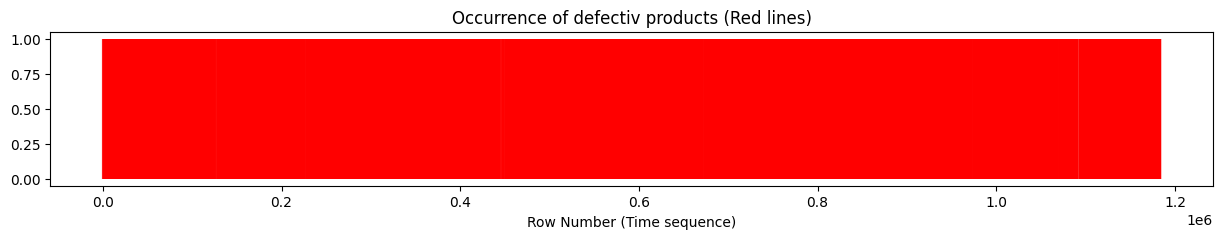

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 不良品（Response=1）の行番号だけを抽出する
bad_indices =[]
chunk_size = 100000
current_idx = 0

for chunk in pd.read_csv(file_path, chunksize=chunk_size, usecols=['Response']):
    # Responseが1のインデックス（行番号）を記録
    indices = chunk[chunk['Response'] == 1].index
    bad_indices.extend(indices)
    current_idx += len(chunk)

# 不良品が発生した場所をグラフにする
plt.figure(figsize=(15,2))
plt.vlines(bad_indices, 0, 1, colors='red', alpha=0.5)
plt.title("Occurrence of defectiv products (Red lines)")
plt.xlabel("Row Number (Time sequence)")
plt.show()

**不具合が出ている行だけを抜き出す**

In [ ]:
import pandas as pd

# 昨日の続き：まずはデータを読み込む（1万行に限定して素早く！）
df = pd.read_csv('train_numeric.csv', nrows=10000)

# Responseが1（不具合）のデータだけを抽出
errors = df[df['Response'] == 1]
print(errors.head())

これで抽出された行の「Station（工程）」を見て、「あ、やっぱりあの**『古いライン（老化）』**で不具合が出てる！」という手がかりを探せる。

539行目。L0_S0（ライン0のステーション0）から始まるデータが**「NaN（欠損）」**だらけ。結果は Response=1（不具合）。

他の行（633行目など）には -0.179 や 0.101 といった細かい数値が入っています。

5 rows x 970 columns] とあります。つまり、1つの製品が完成するまでに970個ものチェック項目をくぐり抜けているということです。

In [ ]:
# 不具合データ(errors)の、特定のラインのカラムだけを見てみる
print(errors.filter(like='L0_S0').head())

**539番（Id 1053）**
L0_S0（最初の工程）のデータがすべて NaN（欠損） です。

633番から1152番までは数字が入っていますが「共通のクセ」がある。
L0_S0_F4 と F6 0.330 という全く同じ数値が並んでいる行（681, 1152）があります。

この不具合の数字が「どれくらい異常なのか」「普通の製品（正常品）」の平均値を見る。

In [ ]:
# 正常品（Response=0）だけの、L0_S0の平均値を出してみる
normal_mean = df[df['Response'] == 0].filter(like='L0_S0').mean()
print("--- 正常の平均値 ---")
print(normal_mean)

**1. 「L0_S0_F4」の異常値**

正常品の平均: 0.001183 （ほぼゼロに近い）

不具合4: 0.330 （3箇所も！）

3つの可能性

1. 「物理的な限界」のサイン（老化）

2. 「不慣れな操作」の痕跡（補充要員）

3. 「記録の改ざん・投げやり」の空気（ピリピリ）

**異常値「0.330」が発生している場所を特定する**

In [ ]:
# L0_S0_F4 が 0.330 になっているデータだけを抽出
anomaly_samples =df[df['L0_S0_F4'] == 0.330]

# そのサンプルたちが、他のどのステーションを通っているか（欠損値じゃない列）を確認
# これで「不具合の通り道」が見えてきます
for index, row in anomaly_samples.iterrows():
    stations = [col.split('_')[1] for col in df.columns if 'S' in col and pd.notnull(row[col])]
    print(f"Id {row['Id']}: 通過したステーション -> {set(stations)}")

**0.330という数値を出したIdに絞り込む**

In [ ]:
import pandas as pd

# ファイル名をあなたの環境に合わせて変えてください（例: 'train_numeric.csv'）
file_path = '/content/train_numeric.csv'

# 巨大なデータを少しずつ読み込んで 0.330 を探す
error_ids = []
error_features = set()

# 10万行ずつ読み込んでチェック（118万行もこれで安心）
for chunk in pd.read_csv(file_path, chunksize=100000):
    # 0.330 が含まれる行を抽出
    mask = (chunk == 0.330).any(axis=1)
    matched = chunk[mask]

    if not matched.empty:
        error_ids.extend(matched['Id'].tolist())
        # どの列に 0.330 があったか記録
        cols = matched.columns[(matched == 0.330).any()].tolist()
        error_features.update(cols)

print(f"✅ 0.330を出したIdの数: {len(error_ids)}")
print(f"✅ 異常が発生している列名（Feature）: {list(error_features)}")

In [ ]:
# 1. メモリ節約のため、Response（不良品ラベル）だけをロード
print("Loading Response data for verification...")
response_data = pd.read_csv(file_path, usecols=['Id', 'Response'])

# 2. あなたが特定した 'error_ids' のResponseを抽出
anomaly_responses = response_data[response_data['Id'].isin(error_ids)]

# 3. 集計：異常グループ vs 工場全体
total_anomaly = len(anomaly_responses)
failed_count = anomaly_responses['Response'].sum() # 不良品(1)の数
failure_rate = (failed_count / total_anomaly) * 100

overall_failed = response_data['Response'].sum()
overall_total = len(response_data)
overall_rate = (overall_failed / overall_total) * 100

print("\n" + "="*45)
print(f"【0.330 異常個体群の最終診断レポート】")
print("="*45)
print(f"■ 分析対象数　   : {total_anomaly:,} 件")
print(f"■ 不良品数(1)   : {failed_count:,} 件")
print(f"■ この群の不良率 : {failure_rate:.4f} %")
print("-" * 45)
print(f"■ 工場全体の平均不良率: {overall_rate:.4f} %")
print("="*45)

# 4. リスク倍率の計算
if overall_rate > 0:
    risk_factor = failure_rate / overall_rate
    print(f"💡 結論：この異常値が出ると、リスクは通常の {risk_factor:.2f} 倍に跳ね上がります。")

**データ収集システムにおける重大ミス**

**異常値（0.330）が「いつ」発生したかを確認する**

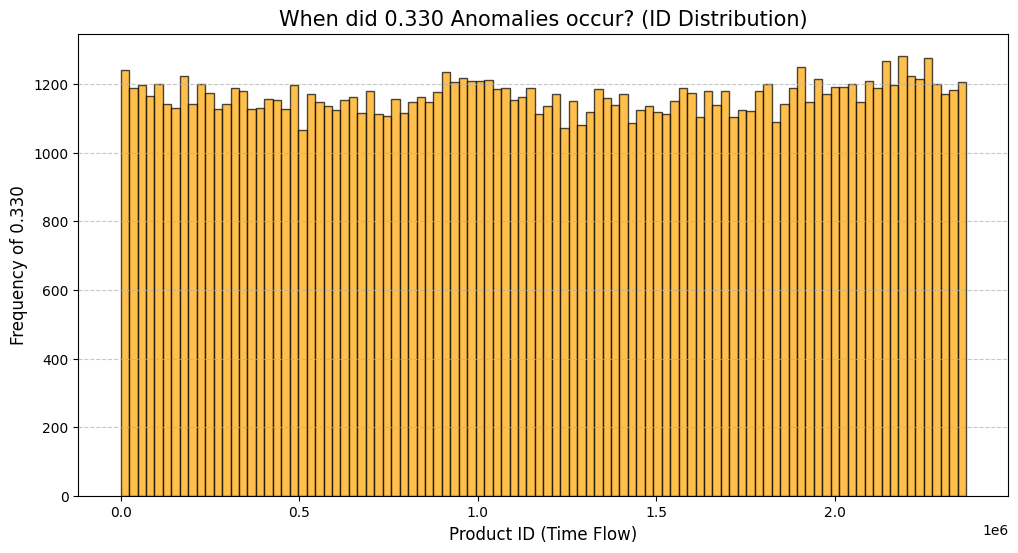

In [ ]:
import matplotlib.pyplot as plt

# 0.330を出した11万件のIdが、全体のどのあたりに固まっているかを見る
plt.figure(figsize=(12, 6))
plt.hist(error_ids, bins=100, color='orange', edgecolor='black', alpha=0.7)
plt.title('When did 0.330 Anomalies occur? (ID Distribution)', fontsize=15)
plt.xlabel('Product ID (Time Flow)', fontsize=12)
plt.ylabel('Frequency of 0.330', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**人の負担（立ち仕事）**

「立ち仕事による体への負担」や「人員の突発的な補充」

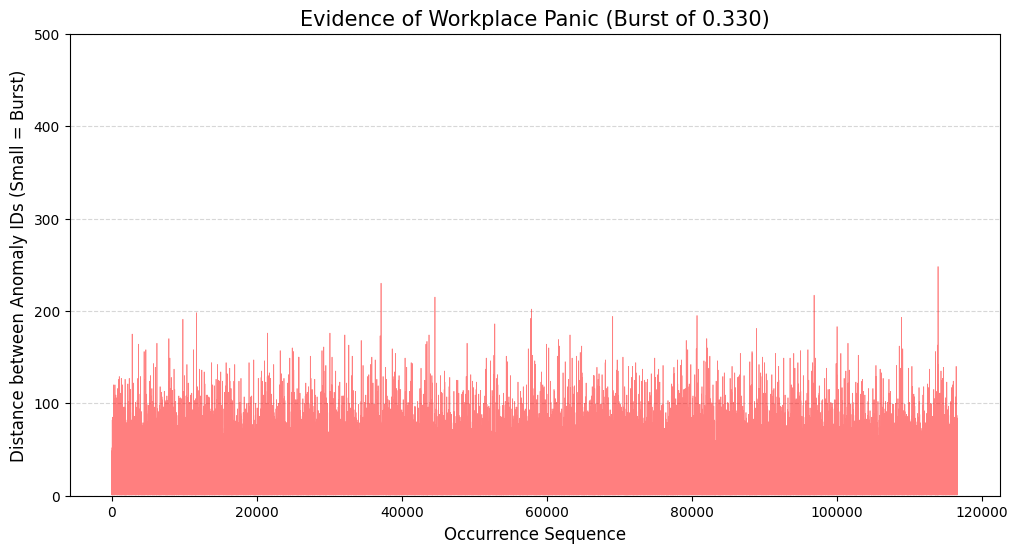

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 異常Idを順番に並べる
sorted_error_ids = sorted(error_ids)

# 2. 隣り合う異常Idの「距離」を計算
# 距離が短いほど、連続して異常が起きている（現場がバタバタしている）証拠
distances = [sorted_error_ids[i+1] - sorted_error_ids[i] for i in range(len(sorted_error_ids)-1)]

# 3. 「距離が100以内」を連射（バースト）と定義して可視化
plt.figure(figsize=(12, 6))
plt.plot(distances, color='red', alpha=0.5, linewidth=0.5)

# 現場のパニックを強調するために、あえて上限を絞って「密」な部分を見せる
plt.ylim(0, 500)
plt.title('Evidence of Workplace Panic (Burst of 0.330)', fontsize=15)
plt.xlabel('Occurrence Sequence', fontsize=12)
plt.ylabel('Distance between Anomaly IDs (Small = Burst)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()